## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, QuantileTransformer
from sklearn.utils.class_weight import compute_class_weight

In [2]:
DATA_DIR      = Path("~/ml-backdoor-defense/data/0_raw/CIC_IoT_2023").expanduser()

RANDOM_STATE         = 42
TEST_SIZE            = 0.15
VAL_SIZE             = 0.15
NEAR_CONSTANT_THRESH = 0.99999
CORRELATION_THRESH   = 0.99

# Cap majority classes ONLY in train (val/test keep natural distribution).
# DoS/DDoS/Mirai dominate ~85% of flows → cap to prevent train bias.
TRAIN_CAPS = {
    "DoS":   1_500_000,
    "DDoS":  1_500_000,
    "Mirai": 1_500_000,
}

# IoT23 features are aggregated per-flow stats; no identifier columns to drop.
DROP_COLS = []
LABEL_COL = "Label"

# Group raw attack labels into attack families.
GROUPS = {
    "DDoS": [
        "DDOS-RSTFINFLOOD", "DDOS-PSHACK_FLOOD", "DDOS-SYN_FLOOD",
        "DDOS-UDP_FLOOD", "DDOS-TCP_FLOOD", "DDOS-ICMP_FLOOD",
        "DDOS-SYNONYMOUSIP_FLOOD", "DDOS-ACK_FRAGMENTATION",
        "DDOS-UDP_FRAGMENTATION", "DDOS-ICMP_FRAGMENTATION",
        "DDOS-SLOWLORIS", "DDOS-HTTP_FLOOD",
    ],
    "DoS":    ["DOS-UDP_FLOOD", "DOS-SYN_FLOOD", "DOS-TCP_FLOOD", "DOS-HTTP_FLOOD"],
    "Mirai":  ["MIRAI-GREETH_FLOOD", "MIRAI-GREIP_FLOOD", "MIRAI-UDPPLAIN"],
    "Recon":  ["RECON-PINGSWEEP", "RECON-OSSCAN", "RECON-PORTSCAN",
               "VULNERABILITYSCAN", "RECON-HOSTDISCOVERY"],
    "Spoofing": ["DNS_SPOOFING", "MITM-ARPSPOOFING"],
    "Benign":   ["BENIGNTRAFFIC", "BENIGN"],
    "Web":      ["BROWSERHIJACKING", "BACKDOOR_MALWARE", "XSS",
                 "UPLOADING_ATTACK", "SQLINJECTION", "COMMANDINJECTION"],
    "BruteForce": ["DICTIONARYBRUTEFORCE"],
}

# Dropped: too few samples → unstable baseline (F1 < 0.20 on prior run).
LABELS_TO_DROP = [
    "BruteForce",   #  12,522 samples (0.08%) → F1=0.09, unreliable
    "Web",          #  23,795 samples (0.16%) → F1=0.12, unreliable
]

CLASS_LIST  = ["Benign", "DDoS", "DoS", "Mirai", "Recon", "Spoofing"]
NUM_CLASSES = len(CLASS_LIST)

CSV_FILES = sorted(DATA_DIR.glob("Merged*.csv"))
assert CSV_FILES, f"No CSV files found in {DATA_DIR}"
print(f"Found {len(CSV_FILES)} CSV files  |  {NUM_CLASSES} classes")

Found 63 CSV files  |  6 classes


## 1. Raw Data Quality

In [3]:
rows = []
for path in CSV_FILES:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    num = df.select_dtypes(include=[np.number])
    rows.append({
        "file":       path.name,
        "rows":       len(df),
        "duplicates": int(df.duplicated().sum()),
        "missing":    int(df.isna().sum().sum()),
        "inf":        int(np.isinf(num.to_numpy()).sum()),
        "n_labels":   int(df[LABEL_COL].nunique()),
    })

qdf = pd.DataFrame(rows)
print(qdf.head(10).to_string(index=False))
print(f"...({len(qdf)} files total)")
print(f"\nTotal: rows={qdf['rows'].sum():,}  duplicates={qdf['duplicates'].sum():,}  "
      f"missing={qdf['missing'].sum():,}  inf={qdf['inf'].sum():,}")

        file   rows  duplicates  missing  inf  n_labels
Merged01.csv 712311      167368       22   14        34
Merged02.csv 748585      179907       12   13        34
Merged03.csv 697289      162037       18   17        34
Merged04.csv 676620      155415       28   23        34
Merged05.csv 744804      178616       16   14        34
Merged06.csv 718229      169309       12   12        34
Merged07.csv 702212      163777       22   17        34
Merged08.csv 712220      168022       18   15        34
Merged09.csv 678882      156716       26   16        34
Merged10.csv 916190      238039       16   15        34
...(63 files total)

Total: rows=45,019,243  duplicates=10,705,128  missing=1,498  inf=991


## 2. Load, Clean & Filter

In [4]:
def clean_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df = df.drop(columns=DROP_COLS, errors="ignore").drop_duplicates()
    for col in df.columns:
        if col != LABEL_COL:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


frames = [clean_file(p) for p in CSV_FILES]
df_all = pd.concat(frames, ignore_index=True)
del frames

# Preserve raw sub-attack labels (used later for stratified train cap)
raw_labels = df_all[LABEL_COL].astype(str).str.strip()

# Map raw labels into attack families
mapping = {label: cls for cls, labels in GROUPS.items() for label in labels}
df_all[LABEL_COL] = raw_labels.replace(mapping)

# Drop unwanted families (keep raw_labels aligned)
mask = df_all[LABEL_COL].isin(LABELS_TO_DROP)
print(f"Dropping {mask.sum():,} rows for: {LABELS_TO_DROP}")
df_all = df_all.loc[~mask].reset_index(drop=True)
raw_labels = raw_labels.loc[~mask].reset_index(drop=True)

print(f"\nAfter cleaning & filtering: {len(df_all):,} rows × {df_all.shape[1]} cols")
dist = df_all[LABEL_COL].value_counts()
print("\nClass distribution:")
for cls in CLASS_LIST:
    n = dist.get(cls, 0)
    print(f"  {cls:30s}: {n:>10,}  ({100*n/len(df_all):5.1f}%)")

Dropping 36,317 rows for: ['BruteForce', 'Web']

After cleaning & filtering: 34,276,841 rows × 40 cols

Class distribution:
  Benign                        :  1,050,835  (  3.1%)
  DDoS                          : 23,128,731  ( 67.5%)
  DoS                           :  6,467,624  ( 18.9%)
  Mirai                         :  2,516,391  (  7.3%)
  Recon                         :    660,573  (  1.9%)
  Spoofing                      :    452,687  (  1.3%)


## 3. Feature Selection

In [5]:
X = df_all.drop(columns=[LABEL_COL]).copy()
y = df_all[LABEL_COL].copy()
print(f"Starting features: {X.shape[1]}")

# Step 1: near-constant
drop1 = [c for c in X if X[c].value_counts(normalize=True, dropna=False).iloc[0] > NEAR_CONSTANT_THRESH]
X = X.drop(columns=drop1)
print(f"  Step 1 — near-constant   dropped ({len(drop1)}): {drop1}")

# Step 2: duplicate-value columns (hash + equals to confirm)
seen, drop2 = {}, []
for col in X:
    h = pd.util.hash_pandas_object(X[col]).sum()
    if h in seen and X[col].equals(X[seen[h]]):
        drop2.append(col)
    else:
        seen[h] = col
X = X.drop(columns=drop2)
print(f"  Step 2 — duplicate-value dropped ({len(drop2)}): {drop2}")

# Step 3: high Pearson correlation
print(f"  Step 3 — correlation matrix ({X.shape[1]} × {len(X):,})…")
upper = X.corr(numeric_only=True).abs().where(
    np.triu(np.ones((X.shape[1],) * 2), k=1).astype(bool))
drop3 = [c for c in upper if (upper[c] > CORRELATION_THRESH).any()]
X = X.drop(columns=drop3)
print(f"  Step 3 — high-corr>{CORRELATION_THRESH}  dropped ({len(drop3)}): {drop3}")

FEATURE_NAMES = list(X.columns)
print(f"\nFinal: {len(FEATURE_NAMES)} features")

Starting features: 39
  Step 1 — near-constant   dropped (0): []
  Step 2 — duplicate-value dropped (2): ['LLC', 'Tot size']
  Step 3 — correlation matrix (37 × 34,276,841)…
  Step 3 — high-corr>0.99  dropped (4): ['syn_count', 'fin_count', 'rst_count', 'IPv']

Final: 33 features


## 4. Split / Scale / Encode

In [6]:
VAL_FRAC = VAL_SIZE / (1 - TEST_SIZE)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, stratify=y_tv, random_state=RANDOM_STATE)

# Cap majority classes only in train, stratified by sub-attack-type.
# val/test keep natural distribution.
y_train_raw = raw_labels.loc[y_train.index]
rng = np.random.default_rng(RANDOM_STATE)
keep_idx = pd.Index([])
for cls in CLASS_LIST:
    cls_idx = y_train[y_train == cls].index
    cap = TRAIN_CAPS.get(cls)
    if cap is not None and len(cls_idx) > cap:
        ratio = cap / len(cls_idx)
        sub_labels = y_train_raw.loc[cls_idx]
        sampled = []
        for s in sub_labels.unique():
            s_idx = sub_labels[sub_labels == s].index
            n = int(round(len(s_idx) * ratio))
            sampled.append(rng.choice(s_idx, size=n, replace=False))
        cls_idx = pd.Index(np.concatenate(sampled))
    keep_idx = keep_idx.union(cls_idx)

X_train = X_train.loc[keep_idx].sample(frac=1, random_state=RANDOM_STATE)
y_train = y_train.loc[X_train.index]

scaler = Pipeline([
    ("qt", QuantileTransformer(output_distribution="normal", n_quantiles=1_000,
                               random_state=RANDOM_STATE, subsample=int(1e8))),
    ("mm", MinMaxScaler()),
])
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURE_NAMES, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_NAMES, index=X_test.index)

le = LabelEncoder()
le.fit(CLASS_LIST)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train_enc)

print(f"train {len(X_train):,}  |  val {len(X_val):,}  |  test {len(X_test):,}")
tbl = pd.DataFrame({
    "class":   le.classes_,
    "train_n": [(y_train_enc == i).sum() for i in range(NUM_CLASSES)],
    "pct":     [f"{100*(y_train_enc==i).sum()/len(y_train_enc):.2f}%" for i in range(NUM_CLASSES)],
    "weight":  class_weights.round(2),
})
print(tbl.to_string(index=False))

train 6,014,865  |  val 5,141,526  |  test 5,141,527
   class  train_n    pct  weight
  Benign   735585 12.23%    1.36
    DDoS  1499999 24.94%    0.67
     DoS  1500000 24.94%    0.67
   Mirai  1499999 24.94%    0.67
   Recon   462401  7.69%    2.17
Spoofing   316881  5.27%    3.16


## 5. Sanity Check

In [7]:
for name, Xs, ye in [("train", X_train_s, y_train_enc),
                     ("val",   X_val_s,   y_val_enc),
                     ("test",  X_test_s,  y_test_enc)]:
    n_nan = int(Xs.isna().sum().sum())
    n_inf = int(np.isinf(Xs.to_numpy()).sum())
    missing = [le.classes_[i] for i in range(NUM_CLASSES) if (ye == i).sum() == 0]
    tag = "OK" if n_nan == 0 and n_inf == 0 and not missing else "FAIL"
    print(f"  [{tag}] {name:5s}  shape={Xs.shape}  NaN={n_nan}  inf={n_inf}"
          + (f"  missing={missing}" if missing else ""))

  [OK] train  shape=(6014865, 33)  NaN=0  inf=0
  [OK] val    shape=(5141526, 33)  NaN=0  inf=0
  [OK] test   shape=(5141527, 33)  NaN=0  inf=0


## 6. MLP Baseline

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def to_tensor(Xdf, yarr):
    return (torch.tensor(Xdf.to_numpy(), dtype=torch.float32),
            torch.tensor(yarr, dtype=torch.long))

X_tr_t, y_tr_t = to_tensor(X_train_s, y_train_enc)
X_va_t, y_va_t = to_tensor(X_val_s,   y_val_enc)
X_te_t, y_te_t = to_tensor(X_test_s,  y_test_enc)

BATCH = 4096
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH,   shuffle=True,  num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BATCH*4, shuffle=False, num_workers=0)


class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, p=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model     = MLP(X_tr_t.shape[1], [256, 128, 64], NUM_CLASSES).to(device)
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f"Device: {device}  |  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Device: cuda  |  Trainable params: 51,142


Epoch 01/20  train=0.4805  val_loss=0.4278  val_f1=0.7849 <--
Epoch 02/20  train=0.3993  val_loss=0.4072  val_f1=0.7950 <--
Epoch 03/20  train=0.3888  val_loss=0.4178  val_f1=0.7954 <--
Epoch 04/20  train=0.3829  val_loss=0.4061  val_f1=0.7972 <--
Epoch 05/20  train=0.3785  val_loss=0.4048  val_f1=0.8026 <--
Epoch 06/20  train=0.3752  val_loss=0.4072  val_f1=0.8026
Epoch 07/20  train=0.3731  val_loss=0.4038  val_f1=0.8047 <--
Epoch 08/20  train=0.3701  val_loss=0.3984  val_f1=0.8051 <--
Epoch 09/20  train=0.3683  val_loss=0.4142  val_f1=0.7991
Epoch 10/20  train=0.3664  val_loss=0.3957  val_f1=0.8100 <--
Epoch 11/20  train=0.3650  val_loss=0.3956  val_f1=0.8110 <--
Epoch 12/20  train=0.3635  val_loss=0.4019  val_f1=0.8065
Epoch 13/20  train=0.3624  val_loss=0.4038  val_f1=0.8074
Epoch 14/20  train=0.3613  val_loss=0.3980  val_f1=0.8106
Epoch 15/20  train=0.3603  val_loss=0.4012  val_f1=0.8084
Epoch 16/20  train=0.3594  val_loss=0.3995  val_f1=0.8095

Early stop at epoch 16.

Best val_m

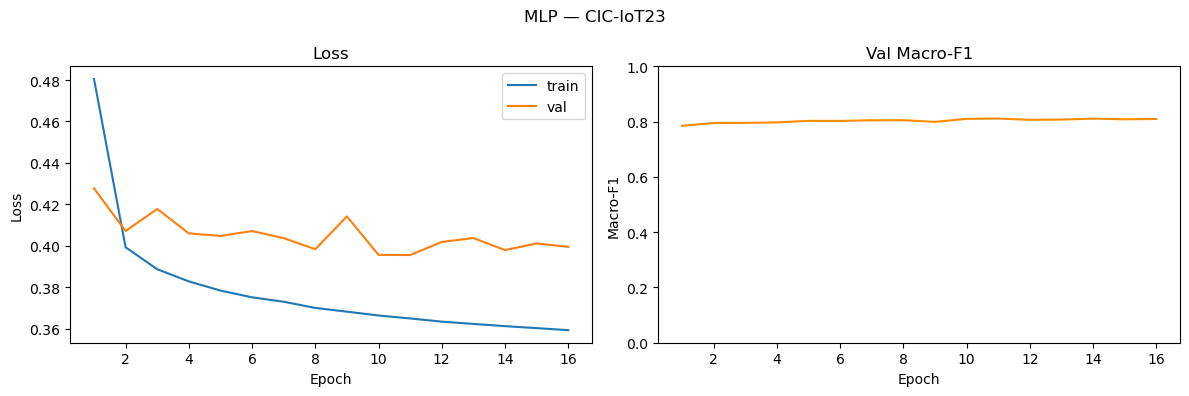

In [9]:
def _eval(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss_sum += criterion(logits, yb).item() * len(yb)
            preds_all.extend(logits.argmax(1).cpu().tolist())
            labels_all.extend(yb.cpu().tolist())
    mf1 = f1_score(labels_all, preds_all, average="macro", zero_division=0)
    return loss_sum / len(labels_all), mf1


MAX_EPOCHS, PATIENCE = 20, 5
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, no_imp, best_state = 0.0, 0, None

for ep in range(1, MAX_EPOCHS + 1):
    model.train()
    run = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        run += loss.item() * len(yb)
    scheduler.step()

    tl = run / len(y_tr_t)
    vl, vf1 = _eval(model, val_loader)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["val_f1"].append(vf1)

    if vf1 > best_f1 + 1e-5:
        best_f1, no_imp = vf1, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = " <--"
    else:
        no_imp += 1
        marker = ""

    print(f"Epoch {ep:02d}/{MAX_EPOCHS}  train={tl:.4f}  val_loss={vl:.4f}  val_f1={vf1:.4f}{marker}")
    if no_imp >= PATIENCE:
        print(f"\nEarly stop at epoch {ep}.")
        break

model.load_state_dict(best_state)
print(f"\nBest val_macro_f1 = {best_f1:.4f}")

eps = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(eps, history["train_loss"], label="train")
ax1.plot(eps, history["val_loss"], label="val")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
ax1.legend()
ax2.plot(eps, history["val_f1"], color="darkorange")
ax2.set(xlabel="Epoch", ylabel="Macro-F1", title="Val Macro-F1", ylim=[0, 1])
plt.suptitle("MLP — CIC-IoT23")
plt.tight_layout()
plt.show()

## 7. Test Evaluation

TEST SET — Classification Report
              precision    recall  f1-score   support

      Benign     0.8452    0.8260    0.8355    157625
        DDoS     0.9544    0.6903    0.8011   3469310
         DoS     0.4440    0.8814    0.5905    970144
       Mirai     0.9881    0.9986    0.9933    377459
       Recon     0.7461    0.7847    0.7649     99086
    Spoofing     0.8854    0.8706    0.8780     67903

    accuracy                         0.7573   5141527
   macro avg     0.8105    0.8419    0.8105   5141527
weighted avg     0.8523    0.7573    0.7769   5141527



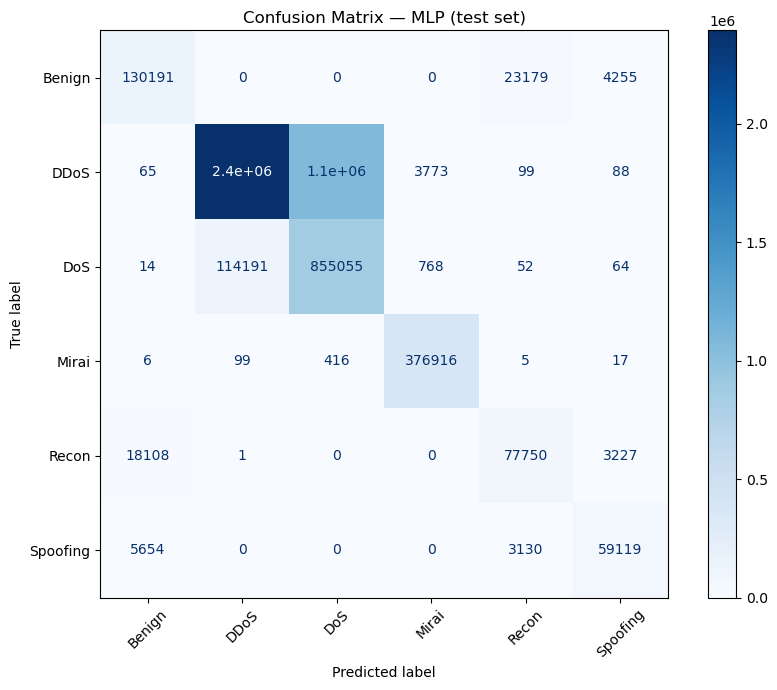


Macro-F1: 0.8105  PASS

Per-class F1:
  Benign                        : 0.8355  ################
  DDoS                          : 0.8011  ################
  DoS                           : 0.5905  ###########
  Mirai                         : 0.9933  ###################
  Recon                         : 0.7649  ###############
  Spoofing                      : 0.8780  #################


In [10]:
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH * 4, shuffle=False)
model.eval()
preds, labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds.extend(model(Xb.to(device)).argmax(1).cpu().tolist())
        labels.extend(yb.tolist())
preds, labels = np.array(preds), np.array(labels)

print("=" * 60)
print("TEST SET — Classification Report")
print("=" * 60)
print(classification_report(labels, preds, target_names=le.classes_, digits=4))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — MLP (test set)"); plt.tight_layout(); plt.show()

macro_f1     = f1_score(labels, preds, average="macro")
per_class_f1 = f1_score(labels, preds, average=None)
print(f"\nMacro-F1: {macro_f1:.4f}  {'PASS' if macro_f1 >= 0.80 else 'FAIL  (target >= 0.80)'}")
print("\nPer-class F1:")
for i, cls in enumerate(le.classes_):
    bar = "#" * int(per_class_f1[i] * 20)
    print(f"  {cls:30s}: {per_class_f1[i]:.4f}  {bar}")